In [3]:
import matplotlib.pyplot as plt
import pickle
import os

In [12]:
dirs_to_load = ["/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/VI/3_0.2_0.9_0.25/tracked_results.pkl"]

In [13]:
all_res = []
for dir in dirs_to_load:
    with open(dir, 'rb') as f:
        tracked_results = pickle.load(f)

    all_res.append(tracked_results)
    

In [16]:
all_res[0].keys()

dict_keys(['baseline_results', 'random_results', 'iter_at_eval'])

In [17]:
def plot_results(results_dict, title):
    baseline = results_dict['baseline_results']
    random = results_dict['random_results']

    baseline_win_rates = [x['win_rate'] for x in baseline]
    random_win_rates = [x['win_rate'] for x in random]

    baseline_draw_rates = [x['draw_rate'] for x in baseline]
    random_draw_rates = [x['draw_rate'] for x in random]

    baseline_loss_rates = [x['loss_rate'] for x in baseline]
    random_loss_rates = [x['loss_rate'] for x in random]

    iterations = results_dict['iter_at_eval']
    # convert to true iteration
    total_states = max(it[1] for it in iterations) + 1 # approx number of states
    iteration_steps = [(it[0]-1) * total_states + it[1] for it in iterations] #-1 because in VI we start counting at 1


    fig, ax = plt.subplots(1,2, figsize=(12,5))
    ax[0].set_title('Baseline Rates')
    ax[0].plot(iteration_steps, baseline_win_rates, label='Win Rate')
    ax[0].plot(iteration_steps, baseline_draw_rates, label='Draw Rate')
    ax[0].plot(iteration_steps, baseline_loss_rates, label='Loss Rate')
    ax[0].set_xlabel('Evaluation Step')
    ax[0].legend()
    ax[0].set_ylabel('Rate')

    ax[1].set_title('Random Rates')
    ax[1].plot(iteration_steps, random_win_rates, label='Win Rate')
    ax[1].plot(iteration_steps, random_draw_rates, label='Draw Rate')
    ax[1].plot(iteration_steps, random_loss_rates, label='Loss Rate')
    ax[1].set_xlabel('Evaluation Step')

    ax[1].legend()
    ax[1].set_ylabel('Rate')

    fig.suptitle(title)

    plt.show()


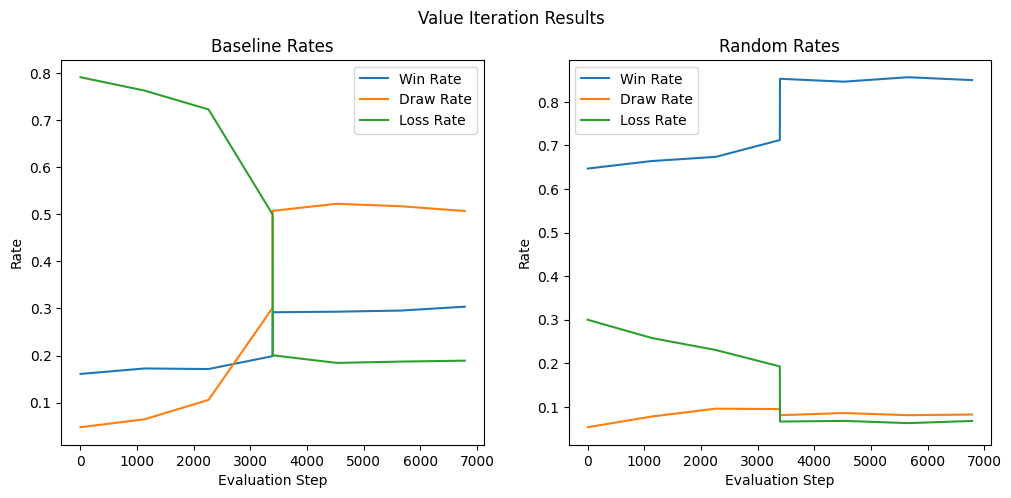

In [19]:
plot_results(all_res[0], "Value Iteration Results")